---

This script implements a Gurobi-based bi-objective optimization model that assigns technicians to farmers for buffalo artificial insemination services while minimizing total travel distance and straw usage from the central office. It considers technician capacity, straw logistics, load balancing, and farmer preferences.

---


This model uses gurobipy to solve the bi-objective optimization problem.

In [ ]:
!pip install gurobipy

---
To demonstrate the solution of the bi-objective optimization problem, we use a sample network consisting of 12 nodes (representing the office, technicians, and farmers) interconnected by 20 edges.

---

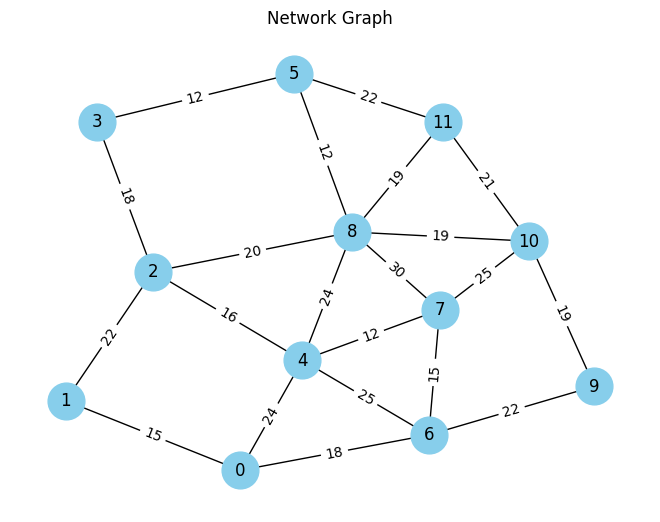

In [ ]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Edge-based node-to-node distance matrix
distance= np.array([
    [0, 15, 0, 0, 24, 0, 18, 0, 0, 0, 0, 0],
    [15, 0, 22, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 22, 0, 18, 16, 0, 0, 0, 20, 0, 0, 0],
    [0, 0, 18, 0, 0, 12, 0, 0, 0, 0, 0, 0],
    [24, 0, 16, 0, 0, 0, 25, 12, 24, 0, 0, 0],
    [0, 0, 0, 12, 0, 0, 0, 0, 12, 0, 0, 22],
    [18, 0, 0, 0, 25, 0, 0, 15, 0, 22, 0, 0],
    [0, 0, 0, 0, 12, 0, 15, 0, 30, 0, 25, 0],
    [0, 0, 20, 0, 24, 12, 0, 30, 0, 0, 19, 19],
    [0, 0, 0, 0, 0, 0, 22, 0, 0, 0, 19, 0],
    [0, 0, 0, 0, 0, 0, 0, 25, 19, 19, 0, 21],
    [0, 0, 0, 0, 0, 22, 0, 0, 19, 0, 21, 0]
])

def plot_graph(distance_matrix):
    G = nx.Graph()

    # Add nodes to the graph
    n = len(distance_matrix)
    G.add_nodes_from(range(n))

    # Add edges to the graph with weights from the distance matrix
    for i in range(n):
        for j in range(n):
            if distance_matrix[i][j] != 0:
                G.add_edge(i, j, weight=distance_matrix[i][j])

    # Draw the graph
    pos = nx.spring_layout(G)
    labels = nx.get_edge_attributes(G, 'weight')
    nx.draw(G, pos, with_labels=True, node_size=700, node_color='skyblue')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=labels)
    plt.title("Network Graph")
    plt.show()

plot_graph(distance)

---
This is the first sample problem (without farmer preference) used to demonstrate the model. The key elements are as follows:

* **Technicians:** Nodes 4 and 8 are designated as AI technicians.
* **Farmers:** Nodes 0, 2, 3, 5, 6, 7, 9, 10, and 11 represent farmers that need to be assigned to a technician.
* **Office:** Node 1 serves as the central office or semen bank, where technicians can refill their straws.
* **Technician limits:** Each technician can serve up to 5 farmers (`tech_limits`).
* **Carrying capacity:** Technician 4 starts with 2 straws, and Technician 8 starts with 1 straw (`carrying_straws`).
* **Farmer preferences:** Currently empty (`farmer_preferences = {}`), indicating no explicit technician preferences from farmers.
* **Total straws available:** A maximum of 12 straws can be refilled from the office (`total_straws_available`).

---

In [ ]:
technicians = [4, 8]
farmers = [0, 2, 3, 5, 6, 7, 9, 10,11]
office = 1
tech_limits = {4: 5, 8: 5}
carrying_straws = {4: 2, 8: 1}
farmer_preferences = {}
total_straws_available = 12


# Weights for bi-objective
w_d = 1
w_s= 1

---
Since the input is provided as an edge-based node-to-node distance  matrix, we compute the farmer-to-technician shortest distance matrix using Dijkstra’s algorithm.

---

In [ ]:
def compute_dijkstra_distances(distance_matrix, farmers, technicians):
    # Build graph
    G = nx.Graph()
    num_nodes = distance_matrix.shape[0]

    # Add edges where distance is non-zero and not a self-loop
    for i in range(num_nodes):
        for j in range(num_nodes):
            if distance_matrix[i, j] > 0:
                G.add_edge(i, j, weight=distance_matrix[i, j])

    # Compute Dijkstra distances
    distance_full = np.zeros((len(farmers), len(technicians)))
    for i, f in enumerate(farmers):
        for j, t in enumerate(technicians):
            try:
                distance_full[i, j] = nx.dijkstra_path_length(G, f, t, weight='weight')
            except nx.NetworkXNoPath:
                distance_full[i, j] = 9999  # Use a large value for unreachable pairs
    return distance_full

# Call the function
distance_full = compute_dijkstra_distances(distance, farmers, technicians)
print("Distance Matrix (rows=farmers, cols=technicians):\n", distance_full)

Distance Matrix (rows=farmers, cols=technicians):
 [[24. 48.]
 [16. 20.]
 [34. 24.]
 [36. 12.]
 [25. 45.]
 [12. 30.]
 [47. 38.]
 [37. 19.]
 [43. 19.]]


---
We build the **penalty matrix `w_tf`**, where each entry represents the penalty for assigning a farmer to a technician. By default, the penalty is 10, but it is set to 0 if the farmer is assigned to their preferred technician.

---


In [ ]:
def build_penalty_matrix(farmers, technicians, farmer_preferences, default_penalty=10, preferred_penalty=0):
    # Initialize penalty matrix
    w_tf = np.full((len(farmers), len(technicians)), default_penalty)

    # Apply preferences
    for i, f in enumerate(farmers):
        if f in farmer_preferences:
            preferred = farmer_preferences[f]
            if preferred in technicians:
                j = technicians.index(preferred)
                w_tf[i, j] = preferred_penalty
    return w_tf

# Call the function
w_tf = build_penalty_matrix(farmers, technicians, farmer_preferences)
print("\n Penalty Matrix (w_tf):\n", w_tf)


 Penalty Matrix (w_tf):
 [[10 10]
 [10 10]
 [10 10]
 [10 10]
 [10 10]
 [10 10]
 [10 10]
 [10 10]
 [10 10]]


---
### **Objective**

The goal of the model is to **minimize two things simultaneously**:

1. The **total travel distance** between technicians and the farmers they are assigned to.
2. The **total number of straws** that technicians need to refill from the central office.

These two objectives are combined using weights, allowing flexibility in prioritizing either distance or straw usage.

---

###  **Constraints**

1. **Each farmer must be assigned to exactly one technician.**
   No farmer is left unassigned, and each farmer can only have one technician.

2. **Technicians can only handle a limited number of farmers.**
   Each technician has a maximum number of farmers they are allowed to serve.

3. **Technicians must have enough straws to serve their assigned farmers.**
   The total number of straws they carry (initial supply + refilled from the office) must be at least equal to the number of farmers assigned to them.

4. **The total number of straws taken from the office is limited.**
   There is a maximum number of straws available for refilling at the central office.

5. **Farmer workload should be balanced across technicians.**
   The number of farmers assigned to each technician should be roughly equal, allowing a difference of at most one.

6. **Farmer preferences are respected (if given).**
   If a farmer has a preferred technician, the model enforces that preference, as long as the technician is available.

  ---


In [ ]:
import numpy as np
import networkx as nx
import gurobipy as gp
from gurobipy import GRB

def solve_technician_assignment(
    farmers, technicians, distance_full, w_tf,
    tech_limits, carrying_straws, total_straws_available,
    farmer_preferences,
    w_d=1, w_s=1
):
    # Initialize model
    model = gp.Model("ResourceAllocation")
    model.setParam("OutputFlag", 0)

    # Variables
    x = model.addVars(farmers, technicians, vtype=GRB.BINARY, name="x")
    r = model.addVars(technicians, vtype=GRB.INTEGER, name="refill")

    # Objective function
    model.setObjective(
        gp.quicksum((w_d * distance_full[i, j] + w_tf[i, j]) * x[farmers[i], technicians[j]]
                    for i in range(len(farmers)) for j in range(len(technicians))) +
        w_s * gp.quicksum(r[t] for t in technicians),
        GRB.MINIMIZE
    )

    # Constraints

    # 1. Each farmer assigned to one technician
    for f in farmers:
        model.addConstr(gp.quicksum(x[f, t] for t in technicians) == 1)

    # 2. Technician assignment capacity
    for t in technicians:
        model.addConstr(gp.quicksum(x[f, t] for f in farmers) <= tech_limits[t])

    # 3. Straw availability
    for t in technicians:
        model.addConstr(carrying_straws[t] + r[t] >= gp.quicksum(x[f, t] for f in farmers))

    # 4. Refill straw limit
    model.addConstr(gp.quicksum(r[t] for t in technicians) <= total_straws_available)

    # 5. Load balancing
    avg_farmers = len(farmers) // len(technicians)
    for t in technicians:
        model.addConstr(gp.quicksum(x[f, t] for f in farmers) >= avg_farmers - 1)
        model.addConstr(gp.quicksum(x[f, t] for f in farmers) <= avg_farmers + 1)

    # Optimize
    model.optimize()

    tech_farmer_list = {t: [] for t in technicians}  # initialize

    # Results
    if model.status == GRB.OPTIMAL:
        print("\nOptimal Assignment and Straw Distribution:\n")
        print("Objective Function Value:", model.objVal)
        tech_farmer_count = {t: 0 for t in technicians}
        tech_distances = {t: [] for t in technicians}

        for i, f in enumerate(farmers):
            for j, t in enumerate(technicians):
                if x[f, t].X > 0.5:
                    dist = distance_full[i, j]
                    print(f"Farmer {f} → Technician {t} | Distance: {dist}")
                    tech_farmer_count[t] += 1
                    tech_farmer_list[t].append(f)
                    tech_distances[t].append(dist)

        print("\n Technician Summary:")
        for t in technicians:
            assigned = tech_farmer_count[t]
            assigned_farmers = tech_farmer_list[t]
            refill = int(r[t].X)
            carrying = carrying_straws[t]
            total_straws = carrying + refill
            total_dist = sum(tech_distances[t])
            print(f"Technician {t}:")
            print(f"  - Assigned farmers : {assigned} → {assigned_farmers}")
            print(f"  - Total distance    : {total_dist}")
            print(f"  - Carrying straws   : {carrying}")
            print(f"  - Office refill     : {refill}")
            print(f"  - Total straws      : {total_straws}\n")

        total_refilled = sum(r[t].X for t in technicians)
        print(f"Total straws distributed from office: {int(total_refilled)} / {total_straws_available}")

        print("\n Preference Assignment Check:")
        for f, preferred in farmer_preferences.items():
            assigned = None
            for t in technicians:
                if x[f, t].X > 0.5:
                    assigned = t
                    break
            if assigned == preferred:
                print(f"Farmer {f}: ✅ Assigned to preferred Technician {preferred}")
            else:
                print(f"Farmer {f}: ⚠️ Preferred Technician {preferred} not assigned → Assigned to Technician {assigned}")
    else:
        print("❌ No optimal solution found.")

    return tech_farmer_list

In [ ]:
tech_farmer_list = solve_technician_assignment(
    farmers, technicians, distance_full, w_tf,
    tech_limits, carrying_straws, total_straws_available,
    farmer_preferences,
    w_d, w_s
)


Optimal Assignment and Straw Distribution:

Objective Function Value: 285.0
Farmer 0 → Technician 4 | Distance: 24.0
Farmer 2 → Technician 4 | Distance: 16.0
Farmer 3 → Technician 8 | Distance: 24.0
Farmer 5 → Technician 8 | Distance: 12.0
Farmer 6 → Technician 4 | Distance: 25.0
Farmer 7 → Technician 4 | Distance: 12.0
Farmer 9 → Technician 8 | Distance: 38.0
Farmer 10 → Technician 8 | Distance: 19.0
Farmer 11 → Technician 8 | Distance: 19.0

 Technician Summary:
Technician 4:
  - Assigned farmers : 4 → [0, 2, 6, 7]
  - Total distance    : 77.0
  - Carrying straws   : 2
  - Office refill     : 2
  - Total straws      : 4

Technician 8:
  - Assigned farmers : 5 → [3, 5, 9, 10, 11]
  - Total distance    : 112.0
  - Carrying straws   : 1
  - Office refill     : 4
  - Total straws      : 5

Total straws distributed from office: 6 / 12

 Preference Assignment Check:



---

This visualization plots the network of farmers, technicians, and the office using NetworkX and Matplotlib. The nodes are connected based on the non-zero entries in the distance matrix, with edge labels showing the corresponding distances.

* Nodes with the same color represent farmers assigned to the same technician.
* Technician nodes share the same color as their assigned farmers.
* The office node is colored gray to distinguish it from technician-assigned groups.
* A legend is included to indicate each technician’s color, and a spring layout is used for better spacing and clarity.

---

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

def plot_graph(distance_matrix, assigned_farmers, color_map):
    G = nx.Graph()
    n = len(distance_matrix)
    G.add_nodes_from(range(n))

    # Add edges with distances
    for i in range(n):
        for j in range(i+1, n):
            if distance_matrix[i][j] != 0:
                G.add_edge(i, j, weight=distance_matrix[i][j])

    # Assign node colors based on technician assignment
    node_colors = []
    for node in G.nodes():
        color = 'lightgray'
        for tech, farmers in assigned_farmers.items():
            if node == tech or node in farmers:
                color = color_map.get(tech, 'gray')
                break
        node_colors.append(color)

    # Layout and drawing
    pos = nx.spring_layout(G, seed=42)
    edge_labels = nx.get_edge_attributes(G, 'weight')
    nx.draw(G, pos, with_labels=True, node_size=700, node_color=node_colors)
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

    # Legend
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', label=f'Technician {t}',
               markerfacecolor=color_map[t], markersize=10)
        for t in assigned_farmers
    ]
    plt.legend(handles=legend_elements, loc='upper left')
    plt.title("Network Graph Colored by Technician Assignment")
    plt.axis('off')
    plt.show()

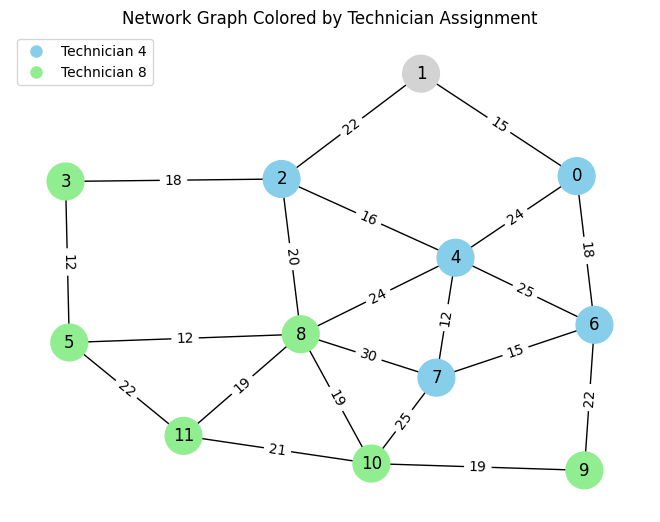

In [ ]:
plot_graph(distance, tech_farmer_list, {
    4: 'skyblue',
    8: 'lightgreen',
})


This is the second sample problem (with farmer preference) used to test the model. The key elements are:

* **Technicians:** Nodes 0, 4, and 5 are designated as AI technicians.
* **Farmers:** Nodes 1, 2, 3, 6, 7, 9, 10, and 11 require insemination services.
* **Office:** Node 8 serves as the central office or semen bank where technicians can refill their straws.
* **Technician limits:** Each technician can serve up to 5 farmers (`tech_limits`).
* **Carrying capacity:** All technicians begin with 1 straw each (`carrying_straws`).
* **Straw availability:** A total of 12 straws are available at the office for refill (`total_straws_available`).
* **Farmer preferences:**

  * Farmer 1 and Farmer 7 prefer Technician 4.
  * Farmer 3 prefers Technician 10 (note: Technician 10 is not in the current technician list, so the model will assign the closest technician instead).


In [ ]:
technicians = [0, 4, 5]
farmers = [1, 2, 3, 6, 7, 9, 10, 11]
office = 8
tech_limits = {0: 5, 4: 5, 5: 5}
carrying_straws = {0: 1, 4: 1, 5: 1}
total_straws_available = 12
farmer_preferences = {1: 4, 7: 4, 3: 10}

In [ ]:
# Technician to Farmer Distance Matrix
distance_full = compute_dijkstra_distances(distance, farmers, technicians)
print(" Distance Matrix (rows=farmers, cols=technicians):\n", distance_full)

 Distance Matrix (rows=farmers, cols=technicians):
 [[15. 38. 52.]
 [37. 16. 30.]
 [55. 34. 12.]
 [18. 25. 57.]
 [33. 12. 42.]
 [40. 47. 50.]
 [58. 37. 31.]
 [67. 43. 22.]]


In [ ]:
# Penalty Matrix for Farmer Preferences
w_tf = build_penalty_matrix(farmers, technicians, farmer_preferences)
print("\n Penalty Matrix (w_tf):\n", w_tf)


 Penalty Matrix (w_tf):
 [[10  0 10]
 [10 10 10]
 [10 10 10]
 [10 10 10]
 [10  0 10]
 [10 10 10]
 [10 10 10]
 [10 10 10]]


In [ ]:
tech_farmer_list = solve_technician_assignment(
    farmers, technicians, distance_full, w_tf,
    tech_limits, carrying_straws, total_straws_available,
    farmer_preferences,
    w_d, w_s
)


Optimal Assignment and Straw Distribution:

Objective Function Value: 241.0
Farmer 1 → Technician 0 | Distance: 15.0
Farmer 2 → Technician 4 | Distance: 16.0
Farmer 3 → Technician 5 | Distance: 12.0
Farmer 6 → Technician 0 | Distance: 18.0
Farmer 7 → Technician 4 | Distance: 12.0
Farmer 9 → Technician 0 | Distance: 40.0
Farmer 10 → Technician 5 | Distance: 31.0
Farmer 11 → Technician 5 | Distance: 22.0

 Technician Summary:
Technician 0:
  - Assigned farmers : 3 → [1, 6, 9]
  - Total distance    : 73.0
  - Carrying straws   : 1
  - Office refill     : 2
  - Total straws      : 3

Technician 4:
  - Assigned farmers : 2 → [2, 7]
  - Total distance    : 28.0
  - Carrying straws   : 1
  - Office refill     : 1
  - Total straws      : 2

Technician 5:
  - Assigned farmers : 3 → [3, 10, 11]
  - Total distance    : 65.0
  - Carrying straws   : 1
  - Office refill     : 2
  - Total straws      : 3

Total straws distributed from office: 5 / 12

 Preference Assignment Check:
Farmer 1: ⚠️ Prefer

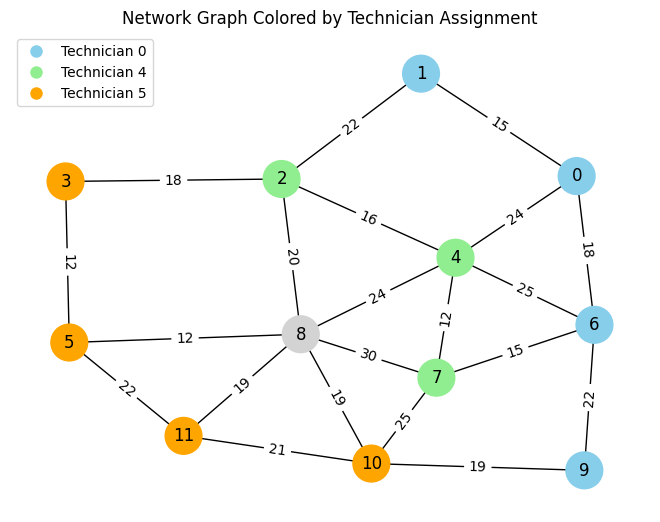

In [ ]:
plot_graph(distance, tech_farmer_list, {
    0: 'skyblue',
    4: 'lightgreen',
    5: 'orange',
})